<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/A_Hybrid_CNN_and_EfficientNetB3_Transfer_Learning_Framework_for_Arsenic_Skin_Disease_Detection(SPlit_Original).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 0 — IMPORTS

In [1]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

STEP 1 — PATHS

In [2]:
original_path = "/content/drive/MyDrive/ArsenicSkinImageBD/Original"

split_path = "/content/drive/MyDrive/ArsenicSplit"

train_path = os.path.join(split_path, "train")
test_path  = os.path.join(split_path, "test")

STEP 2 — DELETE OLD SPLIT STEP 3 — DEFINE CLASSES STEP 4 — CREATE FOLDERS



In [3]:
if os.path.exists(split_path):
    shutil.rmtree(split_path)

print("Old split removed")
classes = ["infacted", "not_infacted"]

for folder in [train_path, test_path]:
    for cls in classes:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

Old split removed


STEP 5 — SPLIT DATA (80/20)

In [4]:
split_ratio = 0.8
random.seed(42)

for cls in classes:
    img_list = os.listdir(os.path.join(original_path, cls))
    random.shuffle(img_list)

    split_index = int(len(img_list) * split_ratio)

    train_imgs = img_list[:split_index]
    test_imgs = img_list[split_index:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(original_path, cls, img),
            os.path.join(train_path, cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(original_path, cls, img),
            os.path.join(test_path, cls, img)
        )

STEP 6 — DATA AUGMENTATION (TRAIN ONLY)

In [5]:
IMG_SIZE = 300
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

STEP 7 — LOAD DATA

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1029 images belonging to 2 classes.
Found 259 images belonging to 2 classes.
{'infacted': 0, 'not_infacted': 1}


STEP 8 — MODEL (EfficientNetB3)

In [7]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(input_layer, output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


STEP 9 — COMPILE

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

STEP 10 — TRAIN

In [9]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5835 - loss: 1.0377 

33/33 ━━━━━━━━━━━━━━━━━━━━ 563s 16s/step - accuracy: 0.6453 - loss: 0.8700 - val_accuracy: 0.6873 - val_loss: 0.6028 - learning_rate: 1.0000e-04
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7800 - loss: 0.5589 

33/33 ━━━━━━━━━━━━━━━━━━━━ 526s 16s/step - accuracy: 0.8017 - loss: 0.4831 - val_accuracy: 0.8108 - val_loss: 0.5240 - learning_rate: 1.0000e-04
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8446 - loss: 0.3551 

33/33 ━━━━━━━━━━━━━━━━━━━━ 537s 16s/step - accuracy: 0.8571 - loss: 0.3389 - val_accuracy: 0.8340 - val_loss: 0.4555 - learning_rate: 1.0000e-04
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8868 - loss: 0.3195 

33/33 ━━━━━━━━━━━━━━━━━━━━ 526s 16s/step - accuracy: 0.8824 - loss: 0.3049 - val_accuracy: 0.8610 - val_loss: 0.3939 - learning_rate: 1.0000e-04
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9000 - loss: 0.2494 

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 524s 16s/step - accuracy: 0.9339 - loss: 0.1653 - val_accuracy: 0.9498 - val_loss: 0.1268 - learning_rate: 1.0000e-04
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9387 - loss: 0.1439 

33/33 ━━━━━━━━━━━━━━━━━━━━ 520s 16s/step - accuracy: 0.9339 - loss: 0.1546 - val_accuracy: 0.9498 - val_loss: 0.1220 - learning_rate: 1.0000e-04
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9442 - loss: 0.1474 

33/33 ━━━━━━━━━━━━━━━━━━━━ 522s 16s/step - accuracy: 0.9436 - loss: 0.1471 - val_accuracy: 0.9691 - val_loss: 0.1033 - learning_rate: 1.0000e-04
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9503 - loss: 0.1240 

33/33 ━━━━━━━━━━━━━━━━━━━━ 528s 16s/step - accuracy: 0.9543 - loss: 0.1281 - val_accuracy: 0.9614 - val_loss: 0.0984 - learning_rate: 1.0000e-04
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9728 - loss: 0.0905 

33/33 ━━━━━━━━━━━━━━━━━━━━ 558s 16s/step - accuracy: 0.9679 - loss: 0.0916 - val_accuracy: 0.9691 - val_loss: 0.0891 - learning_rate: 1.0000e-04
Epoch 15/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 533s 16s/step - accuracy: 0.9660 - loss: 0.0883 - val_accuracy: 0.9691 - val_loss: 0.0901 - learning_rate: 1.0000e-04
Epoch 16/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 528s 16s/step - accuracy: 0.9602 - loss: 0.1070 - val_accuracy: 0.9614 - val_loss: 0.0948 - learning_rate: 1.0000e-04
Epoch 17/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 534s 16s/step - accuracy: 0.9524 - loss: 0.1281 - val_accuracy: 0.9653 - val_loss: 0.1055 - learning_rate: 1.0000e-04
Epoch 18/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 527s 16s/step - accuracy: 0.9456 - loss: 0.1140 - val_accuracy: 0.9614 - val_loss: 0.1087 - learning_rate: 3.0000e-05
Epoch 19/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 528s 16s/step - accuracy: 0.9611 - loss: 0.1079 - val_accuracy: 0.9575 - val_loss: 0.1021 - learning_rate: 3.0000e-05
Epoch 20/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 532s 16s/step - accuracy: 0.970

STEP 11 — ACCURACY (%)

In [10]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Accuracy: {:.2f}%".format(acc * 100))
print("="*40)

9/9 ━━━━━━━━━━━━━━━━━━━━ 90s 10s/step - accuracy: 0.9691 - loss: 0.0891
Final Accuracy: 96.91%


STEP 12 — LOSS & ACCURACY CURVES

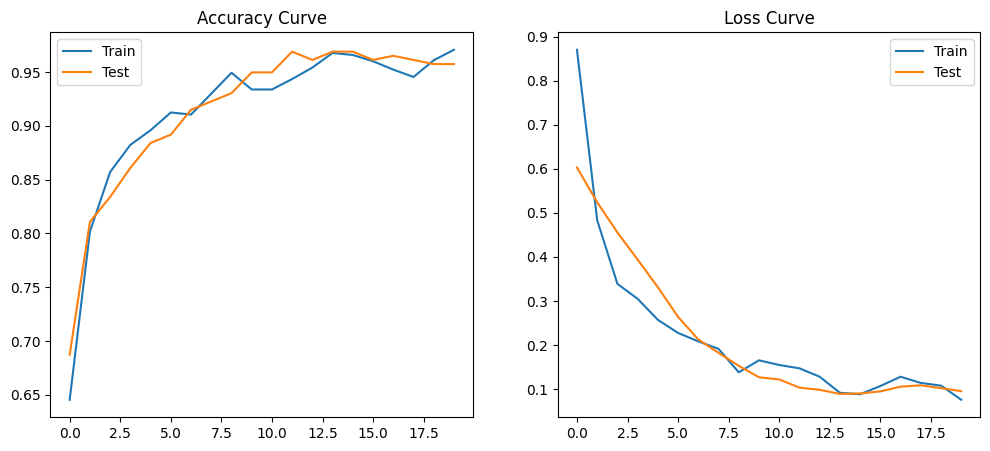

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(['Train','Test'])

plt.show()

STEP 13 — CONFUSION MATRIX

9/9 ━━━━━━━━━━━━━━━━━━━━ 101s 10s/step


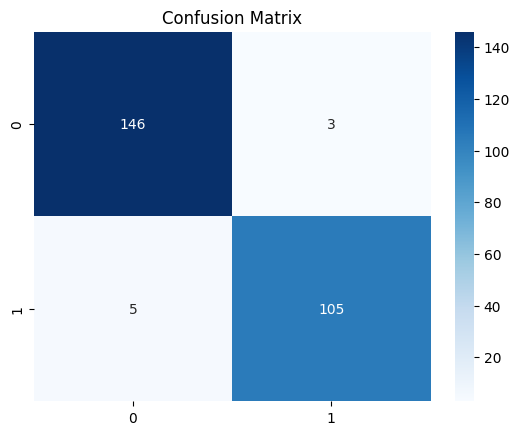

In [12]:
test_generator.reset()
pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

STEP 14 — CLASSIFICATION REPORT

In [13]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

    infacted       0.97      0.98      0.97       149
not_infacted       0.97      0.95      0.96       110

    accuracy                           0.97       259
   macro avg       0.97      0.97      0.97       259
weighted avg       0.97      0.97      0.97       259



STEP 15 — ROC CURVE

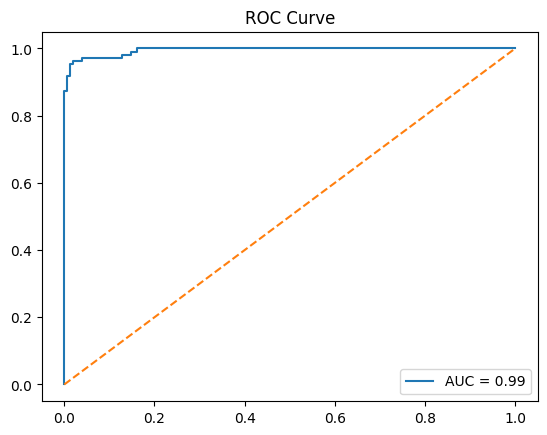

In [14]:
fpr, tpr, _ = roc_curve(y_true, pred[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

Precision–Recall Curve

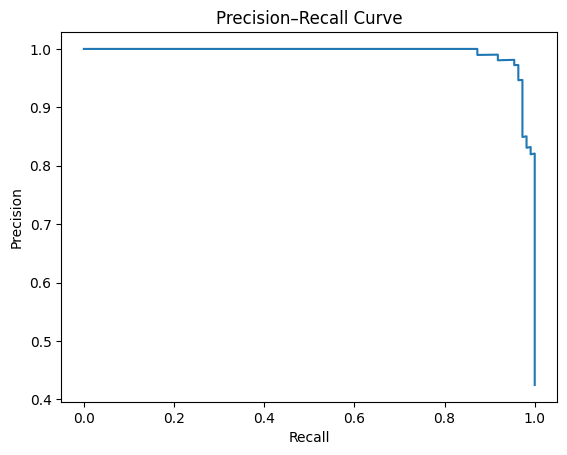

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, pred[:,1])

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

Training vs Validation Accuracy Gap Curve

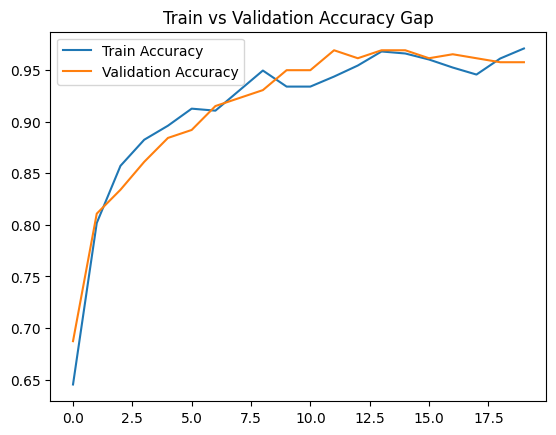

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Train vs Validation Accuracy Gap")
plt.legend()
plt.show()

Train vs Validation Loss Gap Curve

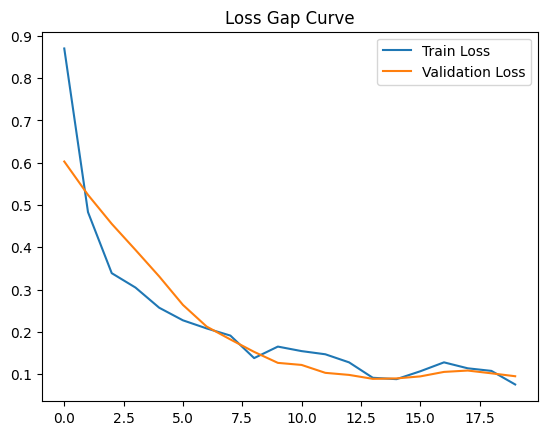

In [17]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Gap Curve")
plt.legend()
plt.show()

F1 Score Curve

In [18]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='binary')
print("F1 Score:", f1)

F1 Score: 0.963302752293578


Confusion Matrix Heatmap

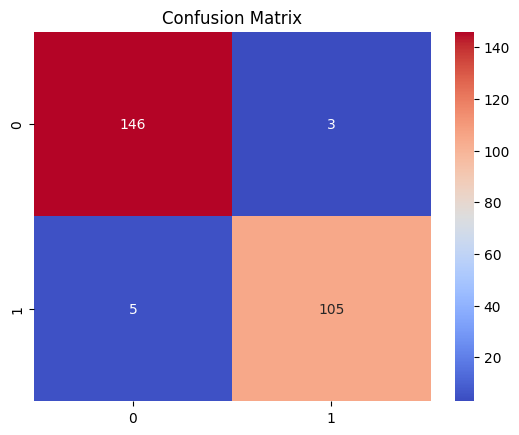

In [19]:
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

Confidence Distribution Curve

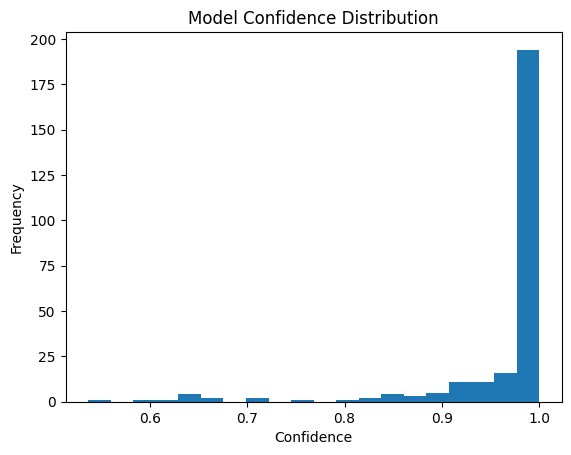

In [20]:
plt.hist(np.max(pred, axis=1), bins=20)
plt.title("Model Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()